In [27]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import get_scorer_names
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.compose import make_column_selector
from sklearn import set_config

In [28]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [29]:
le=LabelEncoder()

X=df_train.drop(columns=['health_condition'])
y = le.fit_transform(df_train['health_condition']) 
test_ids = df_test['id'].copy()

In [30]:
def features(df):
    df=df.copy()
    df=df.drop(columns='id')
    df['stress_level_NaN']=df['stress_level'].isna().astype(int)
    df['sleep_duration_NaN']=df['sleep_duration'].isna().astype(int)
    df['physical_activity_level_NaN']=df['physical_activity_level'].isna().astype(int)
    df['smoking_alcohol_NaN']=df['smoking_alcohol'].isna().astype(int)
    df['calorie_expenditure_NaN']=df['calorie_expenditure'].isna().astype(int)
    df['water_intake_NaN']=df['water_intake'].isna().astype(int)

    df['eau_normal'] = (2 - df['water_intake']).clip(lower=0)    
    df['BMI_normal'] = ((df['bmi'] > 18.5) & (df['bmi'] < 25)).astype(int)
    df['heart_normal'] = ((df['heart_rate'] > 50) & (df['heart_rate'] < 70)).astype(int)
    df['heart_dif']=abs(df['heart_rate']-60)
    df['step_dif']=(10000-df['step_count']).clip(lower=0)
    df['BMI_dif']=abs(df['bmi']-22)
    df['sleep_dif']=abs(df['sleep_duration']-8)
    df['metabolism']=df['calorie_expenditure']/df['exercise_duration']
    df['riskscore']=((df['sleep_duration'] < 6).astype(int)+ (df['stress_level'] == 'high').astype(int)+ (df['physical_activity_level'] == 'sedentary').astype(int))
    return df

features_eng=FunctionTransformer(features)

In [31]:
ord_cols=['sleep_quality','stress_level','smoking_alcohol','physical_activity_level']

obj_cols=X.select_dtypes(include=['object']).columns
cat_cols=[c for c in obj_cols if c not in ord_cols]

bool_cols=X.select_dtypes(include=['bool']).columns
num_cols=X.select_dtypes(include=['number']).columns
num_cols = [c for c in num_cols if c != 'id']

In [32]:
ordi_scales={
    'sleep_quality':['poor','average','good'],
    'stress_level':['high','medium','low'],
    'smoking_alcohol':['yes','occasional','no'],
    'physical_activity_level':['sedentary', 'moderate', 'active']
}

In [33]:
ordinal_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('OrdinalEncoder',OrdinalEncoder(categories=[ordi_scales[c] for c in ord_cols]))
])

cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('OneHotEncoder',OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median'))
])

In [34]:
preprocessor = ColumnTransformer([
    ('ordinal_pipe', ordinal_pipe, ord_cols),
    ('cat_pipe', cat_pipe, cat_cols),
    ('num_pipe', num_pipe, num_cols),
])

logistic_pipe=Pipeline([('features_eng',features_eng),
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('logistic',LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced'))])

In [35]:
scores=cross_val_score(logistic_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("LogisticRegression :", scores.mean(), "+/-", scores.std())

LogisticRegression : 0.8568707209014267 +/- 0.0009819181828851623


In [11]:
random_pipe=Pipeline([('features_eng',features_eng),
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('randomforest',RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1))])

In [75]:
scores=cross_val_score(random_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("RandomForest :", scores.mean(), "+/-", scores.std())

RandomForest : 0.853851643456691 +/- 0.044671320124529804


In [ ]:
light_pipe=Pipeline([('features_eng',features_eng),
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('lgbm',LGBMClassifier(random_state=42,class_weight='balanced',n_jobs=1,verbose=-1))])


In [34]:
scores=cross_val_score(light_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("LightGBM :", scores.mean(), "+/-", scores.std())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/pandas/core/indexes/base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'water_intake'

The above exception was the direct c

In [13]:
param_dist = {
    'lgbm__n_estimators': randint(300, 500),
    'lgbm__learning_rate': loguniform(0.01, 0.1),
    'lgbm__num_leaves': randint(20, 120),
    'lgbm__max_depth': randint(3, 12),
    'lgbm__min_child_samples': randint(10, 100),
    'lgbm__subsample': uniform(0.7, 0.3),          # 0.7 à 1.0
    'lgbm__colsample_bytree': uniform(0.7, 0.3),
    'lgbm__reg_alpha': loguniform(1e-3, 10),
    'lgbm__reg_lambda': loguniform(1e-3, 10),
}

param_grid = {
    'lgbm__n_estimators': [300, 600, 800, 1200],
    'lgbm__learning_rate': np.logspace(-2, -1, 5),
    'lgbm__num_leaves': [20,60,120],
}

In [16]:
import time
t = time.time()
light_pipe.fit(X, y)
print("temps 1 modèle:", time.time() - t)

temps 1 modèle: 18.071122407913208


In [14]:
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=40000, random_state=42, stratify=y)

In [22]:
import time
t = time.time()
light_pipe.fit(X_sample, y_sample)
print("temps 1 modèle:", time.time() - t)

temps 1 modèle: 0.8579039573669434


In [27]:
grid=GridSearchCV(light_pipe,param_grid,cv=5,scoring='balanced_accuracy',n_jobs=-1)
grid.fit(X_sample,y_sample)

print('meilleurs paramètres : ',grid.best_params_)
print('meilleur score',grid.best_score_)

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/skle

meilleurs paramètres :  {'lgbm__learning_rate': np.float64(0.01), 'lgbm__n_estimators': 300, 'lgbm__num_leaves': 20}
meilleur score 0.9074591061191153


In [29]:
best_params = grid.best_params_
final_lgbm = light_pipe.set_params(**best_params)   # applique les meilleurs params
scores = cross_val_score(final_lgbm, X, y, cv=5, scoring='balanced_accuracy', n_jobs=32)
print("Score final sur dataset complet :", scores.mean())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Score final sur dataset complet : 0.9070059089513351


In [ ]:
Randomgrid=RandomizedSearchCV(light_pipe,param_dist,n_iter=100,cv=5,scoring='balanced_accuracy',n_jobs=128)

Randomgrid.fit(X_sample,y_sample)

print('meilleurs paramètres : ',Randomgrid.best_params_)
print('meilleur score',Randomgrid.best_score_)

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/skle

meilleurs paramètres :  {'lgbm__colsample_bytree': np.float64(0.8674917941326343), 'lgbm__learning_rate': np.float64(0.011008711069368788), 'lgbm__max_depth': 4, 'lgbm__min_child_samples': 80, 'lgbm__n_estimators': 427, 'lgbm__num_leaves': 110, 'lgbm__reg_alpha': np.float64(0.012736989139256454), 'lgbm__reg_lambda': np.float64(0.8050553030042714), 'lgbm__subsample': np.float64(0.7890952355311619)}
meilleur score 0.9081725767429741


In [34]:
best_params = Randomgrid.best_params_
final_lgbm = light_pipe.set_params(**best_params)   # applique les meilleurs params
scores = cross_val_score(final_lgbm, X, y, cv=5, scoring='balanced_accuracy', n_jobs=32)
print("Score final sur dataset complet :", scores.mean())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Score final sur dataset complet : 0.9065302443987996


/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


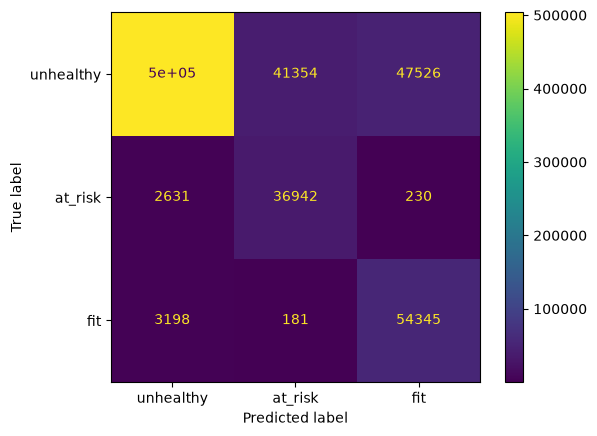

In [ ]:
y_pred=cross_val_predict(final_lgbm,X,y,cv=5,n_jobs=5)
ConfusionMatrixDisplay.from_predictions(y,y_pred,display_labels=['unhealthy','at_risk','fit'])

In [1]:
print(le.classes_)   # te donne l'ordre, donc quel chiffre = unhealthy

NameError: name 'le' is not defined